# Build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc). 

 **Using different classification algorithms to predict the survivability and comparing them for the best fit model**

First step is importing the necessary libraries and reading the data into a dataframe

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
df = pd.read_csv("../input/titanic/train.csv")
df.shape

(891, 12)

In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Checking for Null values

<AxesSubplot:>

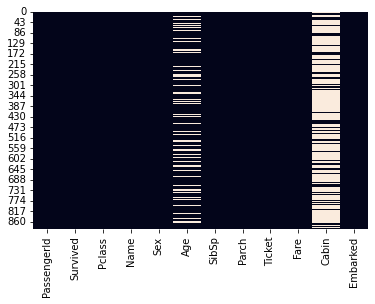

In [3]:

sns.heatmap(df.isnull(),cbar=False)

In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [6]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
#dropping unwanted columns
df.drop(['PassengerId','Name','Ticket','Cabin','Embarked'],axis='columns',inplace=True)

In [8]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


##### Some Visualisations

<AxesSubplot:xlabel='Survived', ylabel='count'>

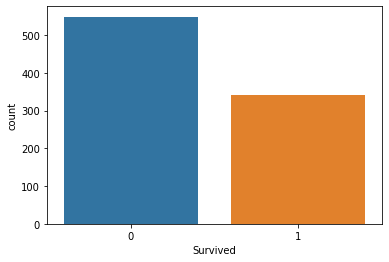

In [9]:
import seaborn as sns
sns.countplot(x="Survived", data = df)

<AxesSubplot:xlabel='Survived', ylabel='count'>

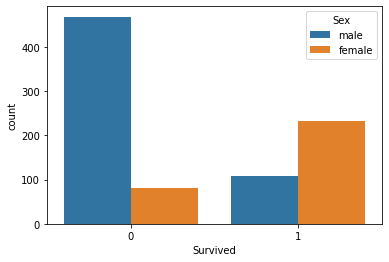

In [10]:
sns.countplot(x="Survived",hue = "Sex", data = df)

Separating the data into dependent and independent variables

In [11]:
inputs = df.drop('Survived',axis='columns')
target = df.Survived

Filling the null values of column age using mean of the existing age data

In [12]:
inputs.Age = inputs.Age.fillna(inputs.Age.mean())

In [13]:
inputs.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,male,22.0,1,0,7.2500
1,1,female,38.0,1,0,71.2833
2,3,female,26.0,0,0,7.9250
3,1,female,35.0,1,0,53.1000
4,3,male,35.0,0,0,8.0500


Performing column transformation on columns "PClass" and "Sex" using OneHotEncoder

In [14]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0, 1])], remainder='passthrough')
inputs= np.array(ct.fit_transform(inputs))

Performing train_test_split on the data

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(inputs,target,test_size=0.2,random_state=1)

In [17]:
len(X_train)

712

In [18]:
len(X_test)

179

In [19]:
print(inputs)

[[ 0.      0.      1.     ...  1.      0.      7.25  ]
 [ 1.      0.      0.     ...  1.      0.     71.2833]
 [ 0.      0.      1.     ...  0.      0.      7.925 ]
 ...
 [ 0.      0.      1.     ...  1.      2.     23.45  ]
 [ 1.      0.      0.     ...  0.      0.     30.    ]
 [ 0.      0.      1.     ...  0.      0.      7.75  ]]


# Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)


Scores = pd.DataFrame({'Actual':y_test,'Predictions':y_pred})
print(Scores)


     Actual  Predictions
862       1            1
223       0            0
84        1            1
680       0            1
535       1            1
..      ...          ...
796       1            1
815       0            0
629       0            0
421       0            0
448       1            1

[179 rows x 2 columns]


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


In [21]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[92 14]
 [21 52]]


0.8044692737430168

<AxesSubplot:>

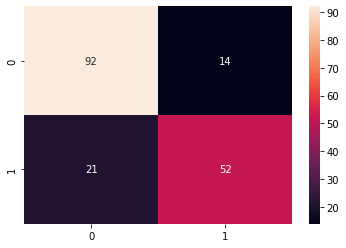

In [22]:
sns.heatmap(cm,annot=True)

# Decision Tree

In [23]:
from sklearn import tree
model1 = tree.DecisionTreeClassifier()

In [24]:
model1.fit(X_train,y_train)
y_pred1=model1.predict(X_test)

In [25]:
cm1 = confusion_matrix(y_test, y_pred1)
print(cm1)
accuracy_score(y_test, y_pred1)


[[91 15]
 [28 45]]


0.7597765363128491

<AxesSubplot:>

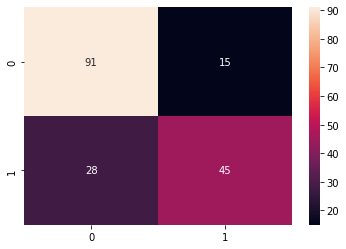

In [26]:
sns.heatmap(cm1,annot=True)

# Support Vector Machine

In [27]:
from sklearn.svm import SVC
model2 = SVC()

model2.fit(X_train, y_train)
y_pred2=model2.predict(X_test)

In [28]:
cm2 = confusion_matrix(y_test, y_pred2)
print(cm2)
accuracy_score(y_test, y_pred2)

[[96 10]
 [51 22]]


0.659217877094972

<AxesSubplot:>

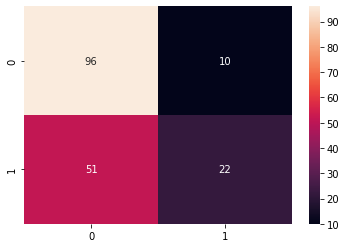

In [29]:
sns.heatmap(cm2,annot=True)

**Comparison of different models**

1. Logistic regression
   Accuracy=0.804

2. Decision Tree
   Accuracy=0.748
   
3. Support Vector machine
   Accuracy=0.659

**Conclusion**

Among the three models used for prediction Logistic Regression has the highest accuracy.